## Analysis

### Load CSV

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path configuration
BASE_DIR = '../data/processed'
SUMMARY_PATH = os.path.join(BASE_DIR, "summary.csv")

In [64]:
if not os.path.exists(SUMMARY_PATH):
    raise FileNotFoundError("summary.csv not found.")

df = pd.read_csv(SUMMARY_PATH)

if df.empty:
    raise ValueError("summary.csv is empty.")

print("Loaded dataframe shape:", df.shape)
df.head()

Loaded dataframe shape: (10, 33)


,experiment_name,display_name,parallelism,machine_name,is_communication,request_throughput_avg,request_latency_avg_ms,request_latency_std_ms,time_to_first_token_avg_ms,time_to_first_token_std_ms,...,ttst_ms_p90,ttst_ms_p99,inter_token_latency_ms_p50,inter_token_latency_ms_p90,inter_token_latency_ms_p99,input_sequence_length_avg,input_sequence_length_std,output_sequence_length_avg,output_sequence_length_std,avg_concurrency
0,N1_tupi_none_long_r1_780636,N1 Tupi None Long R1 780636,Single GPU,tupi3,False,0.109069,9164.210757,74.301313,110.079978,0.731509,...,17.815167,17.911549,17.832636,18.137159,18.443245,1024.0,0.0,507.833333,5.233073,0.999532
1,N1_tupi_none_short_r1_780637,N1 Tupi None Short R1 780637,Single GPU,tupi3,False,0.438948,2276.232712,13.801608,29.588125,0.756325,...,17.684019,17.804670,17.737763,17.761234,17.782169,128.0,0.0,128.000000,0.000000,0.999149
2,N2_poti_TP_long_r1_780629,Tensor Parallelism,TP,poti[1-2],True,0.053102,18828.286171,90.579421,3863.712939,0.859495,...,29.680906,30.905465,29.425559,30.068943,30.272499,1024.0,0.0,508.000000,4.683058,0.999826
3,N2_poti_TP_short_r1_780627,Tensor Parallelism,TP,poti[1-2],True,0.232459,4300.549347,12.317001,546.854121,10.256540,...,29.741952,30.113029,29.534664,29.636528,29.670933,128.0,0.0,128.000000,0.000000,0.999701
4,N4_poti_TP_long_r1_780632,Tensor Parallelism,TP,poti[1-4],True,0.040262,24833.922965,75.676834,5648.875454,7.320081,...,37.752367,41.836440,37.989406,38.454965,40.654969,1024.0,0.0,504.733333,9.043700,0.999862


In [65]:
# =====================================================
# FORCE COMMUNICATION COLUMN TO REAL BOOLEAN
# =====================================================

print(df['is_communication'].unique())

# Convert safely
df['is_communication'] = (
    df['is_communication']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Map explicitly
df['is_communication'] = df['is_communication'].map({
    'true': True,
    'false': False
})

print(df['is_communication'].unique())

[False  True]
[False  True]


### Analysis

In [66]:
experiment_name_mapping = {
    'N1_tupi_none_long_r1_780424': 'tupi (N1) Long Seq',
    'N1_tupi_none_short_r1_780423': 'tupi (N1) Short Seq (2)',
    'N2_poti_PP_long_r1_780376': 'poti (N2) PP Long Seq',
    'N2_poti_PP_short_r1_780413': 'poti (N2) PP Short Seq',
    'N2_poti_TP_short_r1_780378': 'poti (N2) TP Short Seq',
    'N2_poti_TP_long_r1_780377': 'poti (N2) TP Long Seq',
    'N1_tupi_none_short_r1_778989': 'tupi (N1) Short Seq (1)'
}

df['display_name'] = df['experiment_name'].map(experiment_name_mapping)

In [67]:
metrics_to_plot = [
    'request_throughput_avg',
    'request_latency_avg_ms',
    'time_to_first_token_avg_ms',
    'input_sequence_length_avg',
    'output_sequence_length_avg',
    'output_token_throughput_avg',
    'inter_token_latency_avg_ms',
]

In [68]:
# Identify communication experiments (PP / TP)
df['is_communication'] = df['display_name'].str.contains('PP|TP', case=False, na=False)

In [69]:
import pandas as pd
import re


def format_experiment_name(name):
    """
    Convert raw experiment folder names into readable labels.

    Examples:
    ----------
    N1_tupi_none_short_r1_778989
    -> 1 Node TUPI
       No Communication • Short Input

    N2_poti_TP_long_r2_123456
    -> 2 Nodes POTI
       Tensor Parallelism • Long Input

    infer_vllm_778989
    -> Infer VLLM
    """

    # ===== INVALID VALUES =====
    if pd.isna(name):
        return "Unknown"

    if not isinstance(name, str):
        name = str(name)

    # Remove extension/spaces
    name = name.strip()

    # =========================================================
    # STANDARD EXPERIMENT FORMAT
    # =========================================================
    # Expected:
    # N1_tupi_none_short_r1_778989
    # N2_poti_PP_long_r2_123456
    # etc.
    # =========================================================
    pattern = (
        r'^(N\d+)_([A-Za-z0-9]+)_(none|PP|TP)_'
        r'(short|long)'
    )

    match = re.match(pattern, name, re.IGNORECASE)

    if match:
        n_nodes, system, strategy, length = match.groups()

        # ===== NODES =====
        node_count = int(n_nodes[1:])

        if node_count == 1:
            nodes_label = "1 Node"
        else:
            nodes_label = f"{node_count} Nodes"

        # ===== SYSTEM =====
        system = system.upper()

        # ===== STRATEGY =====
        strategy_map = {
            'none': 'No Communication',
            'pp': 'Pipeline Parallelism',
            'tp': 'Tensor Parallelism'
        }

        strategy_label = strategy_map.get(
            strategy.lower(),
            strategy
        )

        # ===== INPUT LENGTH =====
        length_map = {
            'short': 'Short Input',
            'long': 'Long Input'
        }

        length_label = length_map.get(
            length.lower(),
            length
        )

        # ===== FINAL LABEL =====
        return (
            f"{nodes_label} • {system}\n"
            f"{strategy_label} • {length_label}"
        )

    # =========================================================
    # GENERIC FALLBACKS
    # =========================================================

    # infer_vllm_778989
    if name.startswith("infer_vllm"):
        return "Inference • vLLM"

    # telemetry / profiling / misc
    cleaned = (
        name.replace('_', ' ')
            .replace('-', ' ')
            .title()
    )

    return cleaned

In [70]:
def get_ylabel(metric_name):
    name = metric_name.lower()

    if 'latency' in name:
        return 'Latency (ms)'
    elif 'throughput' in name:
        return 'Throughput (tokens/s)'
    elif 'tokens_per_second' in name:
        return 'Throughput (tokens/s)'
    elif 'time' in name:
        return 'Time (ms)'
    elif 'ttft' in name:
        return 'Time to First Token (ms)'
    else:
        return 'Value'

In [71]:
def pretty_metric_name(metric_name):
    return (
        metric_name
        .replace('_avg_ms', '')
        .replace('_avg', '')
        .replace('_', ' ')
        .title()
    )

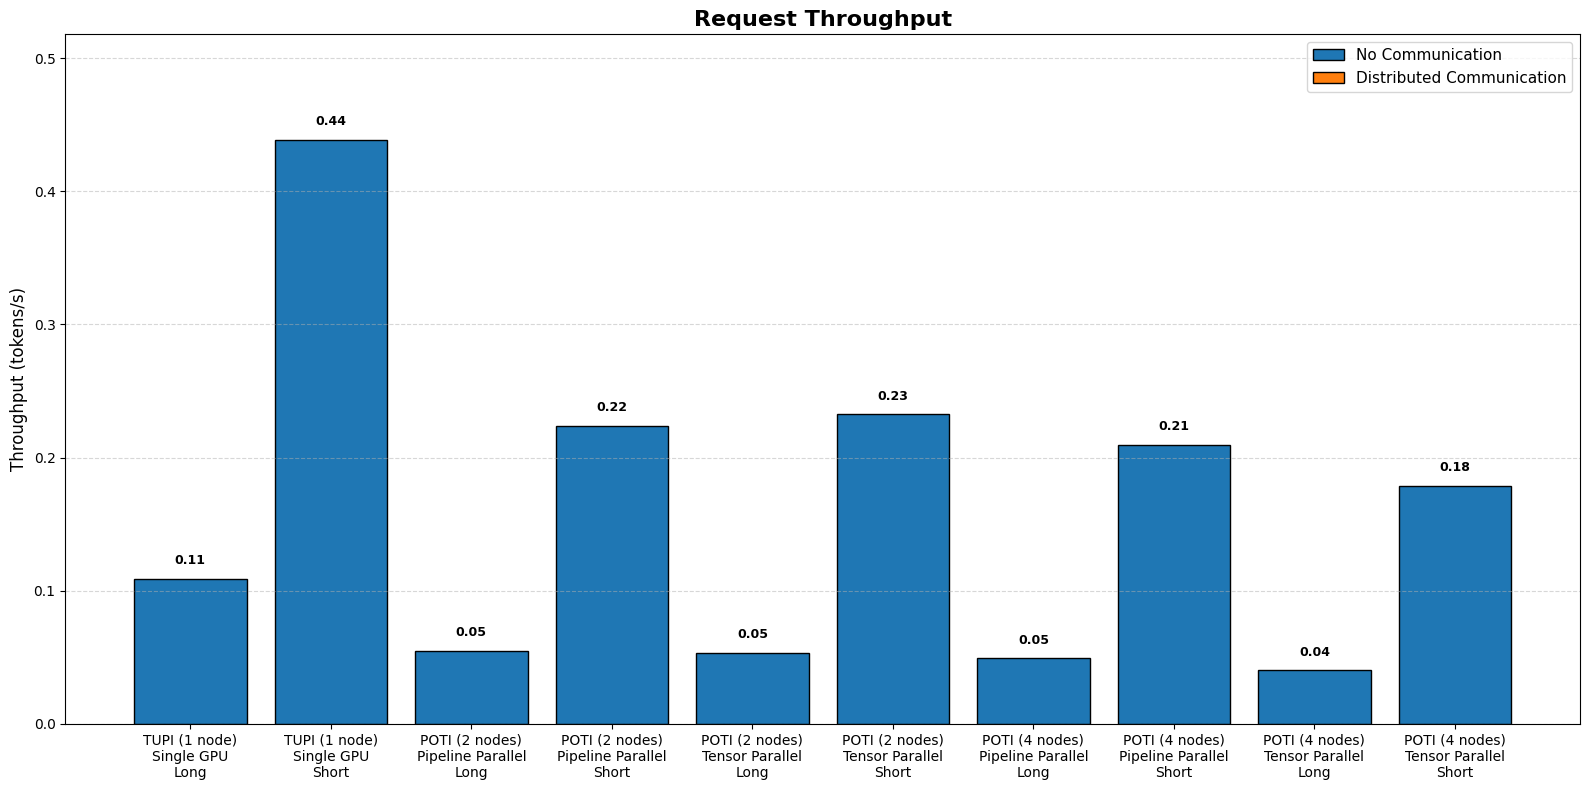

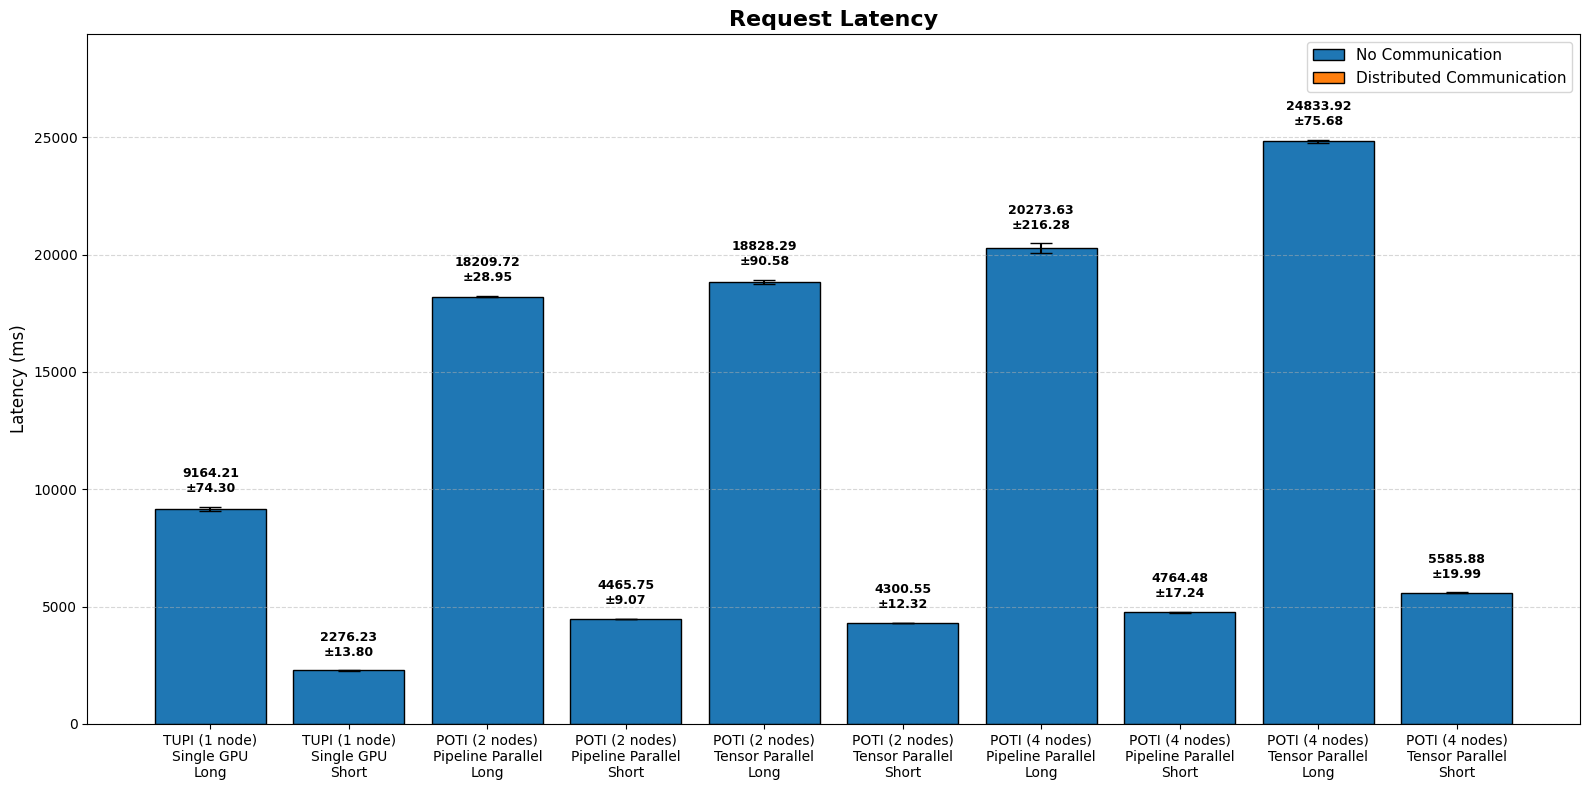

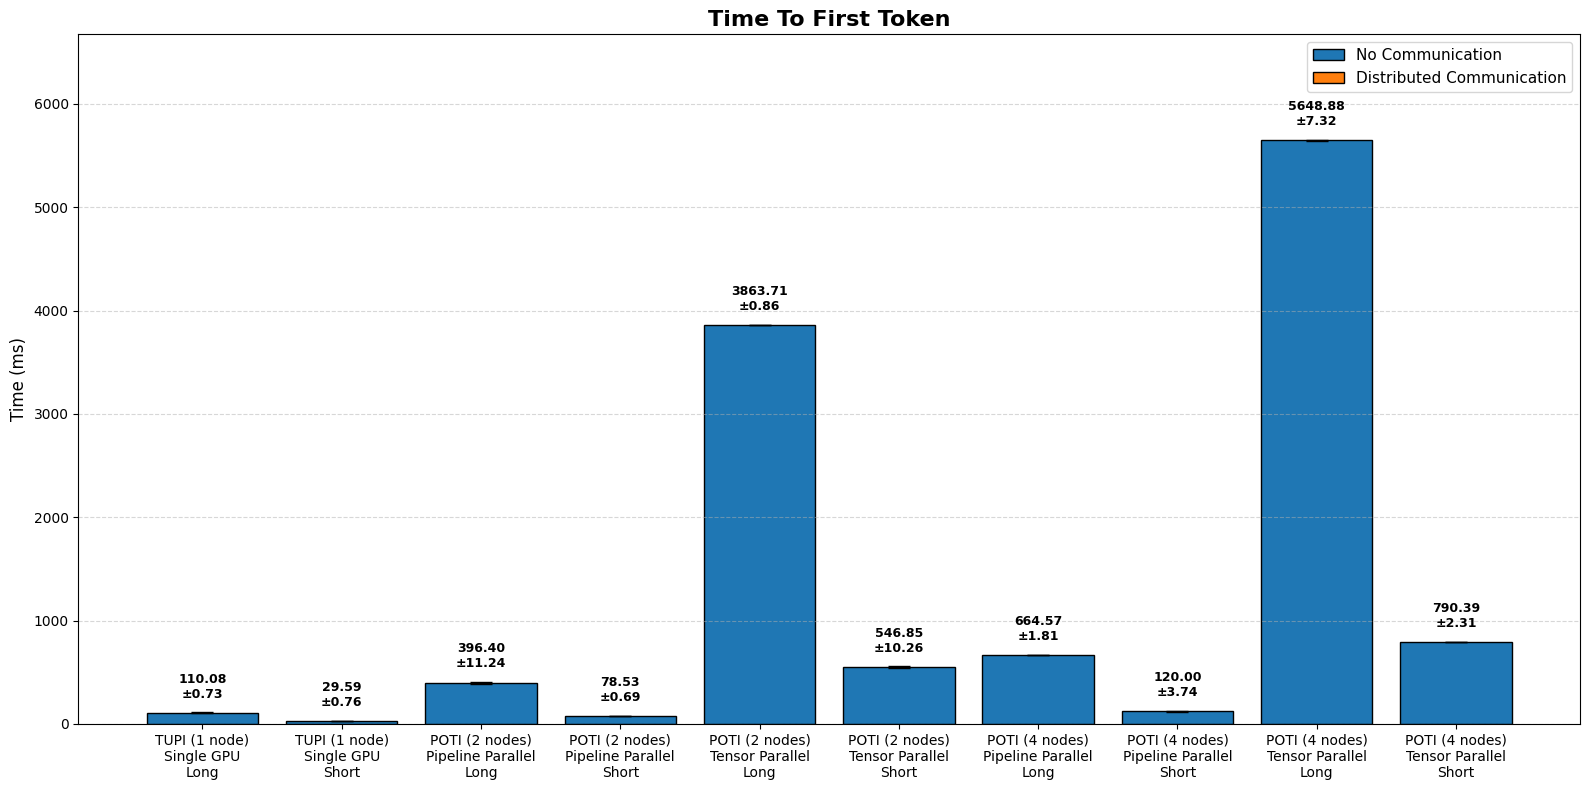

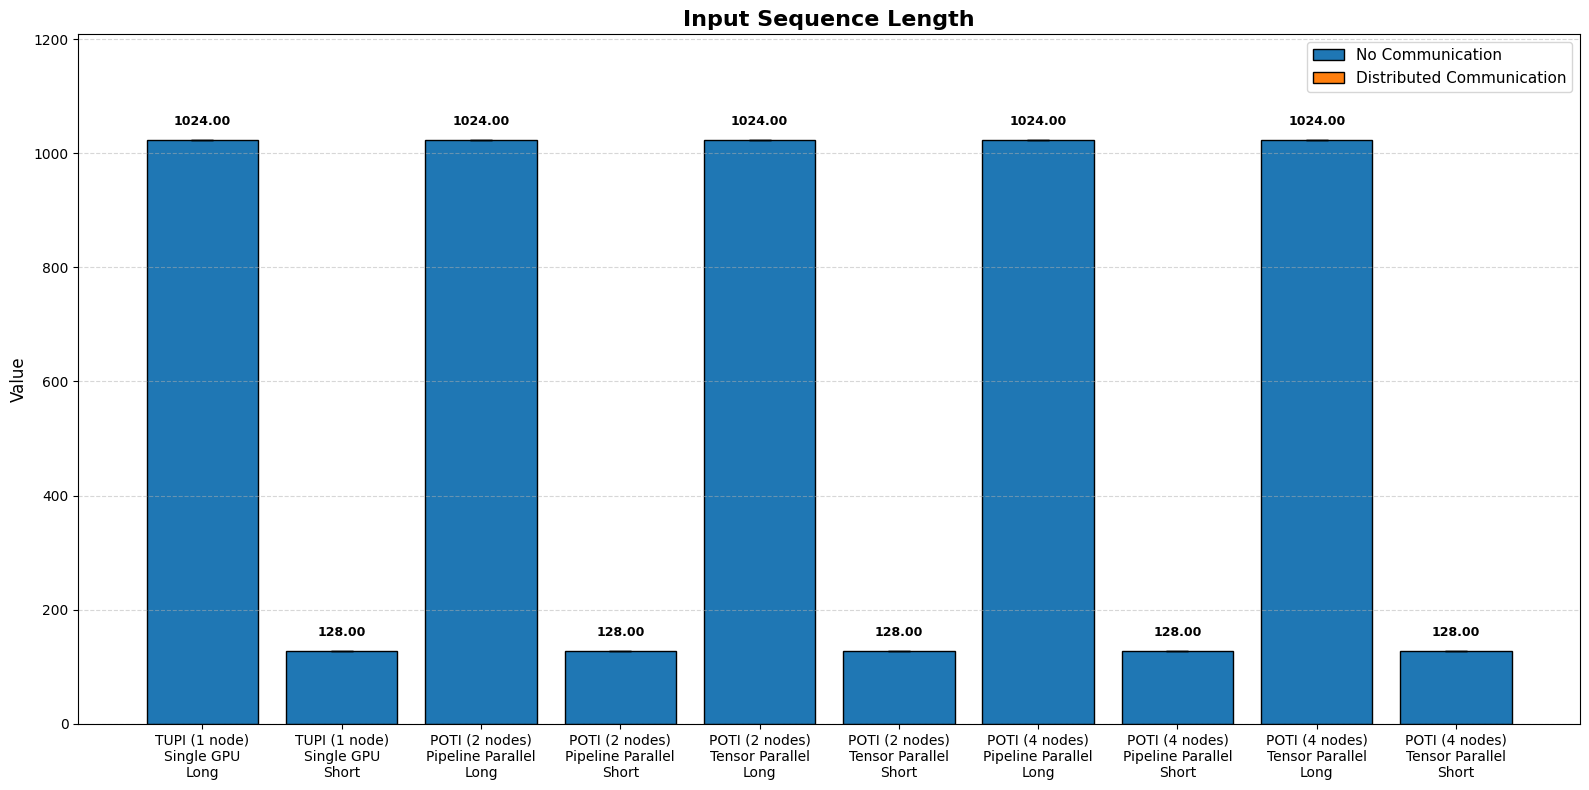

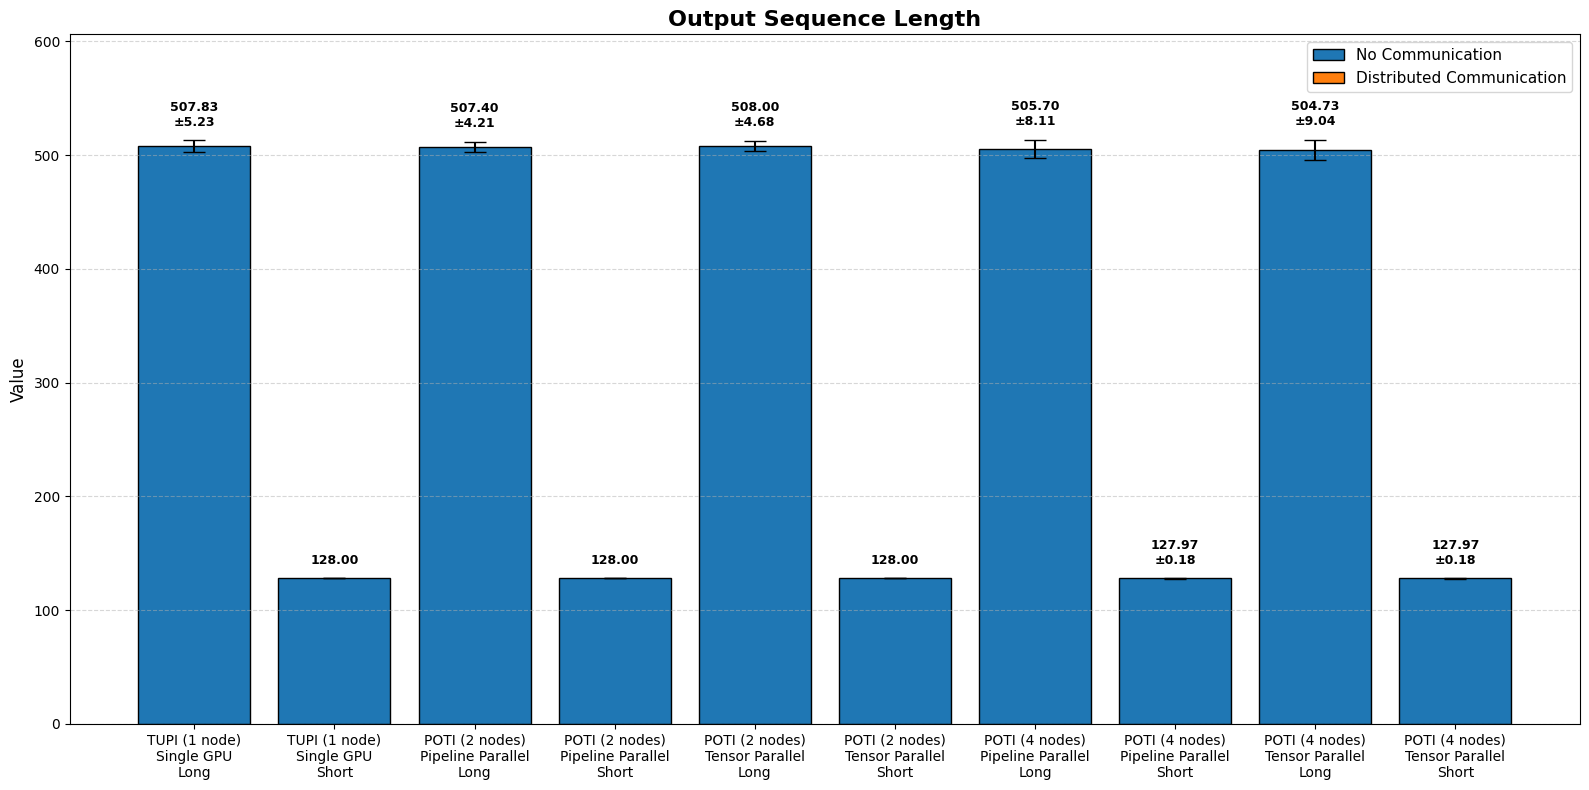

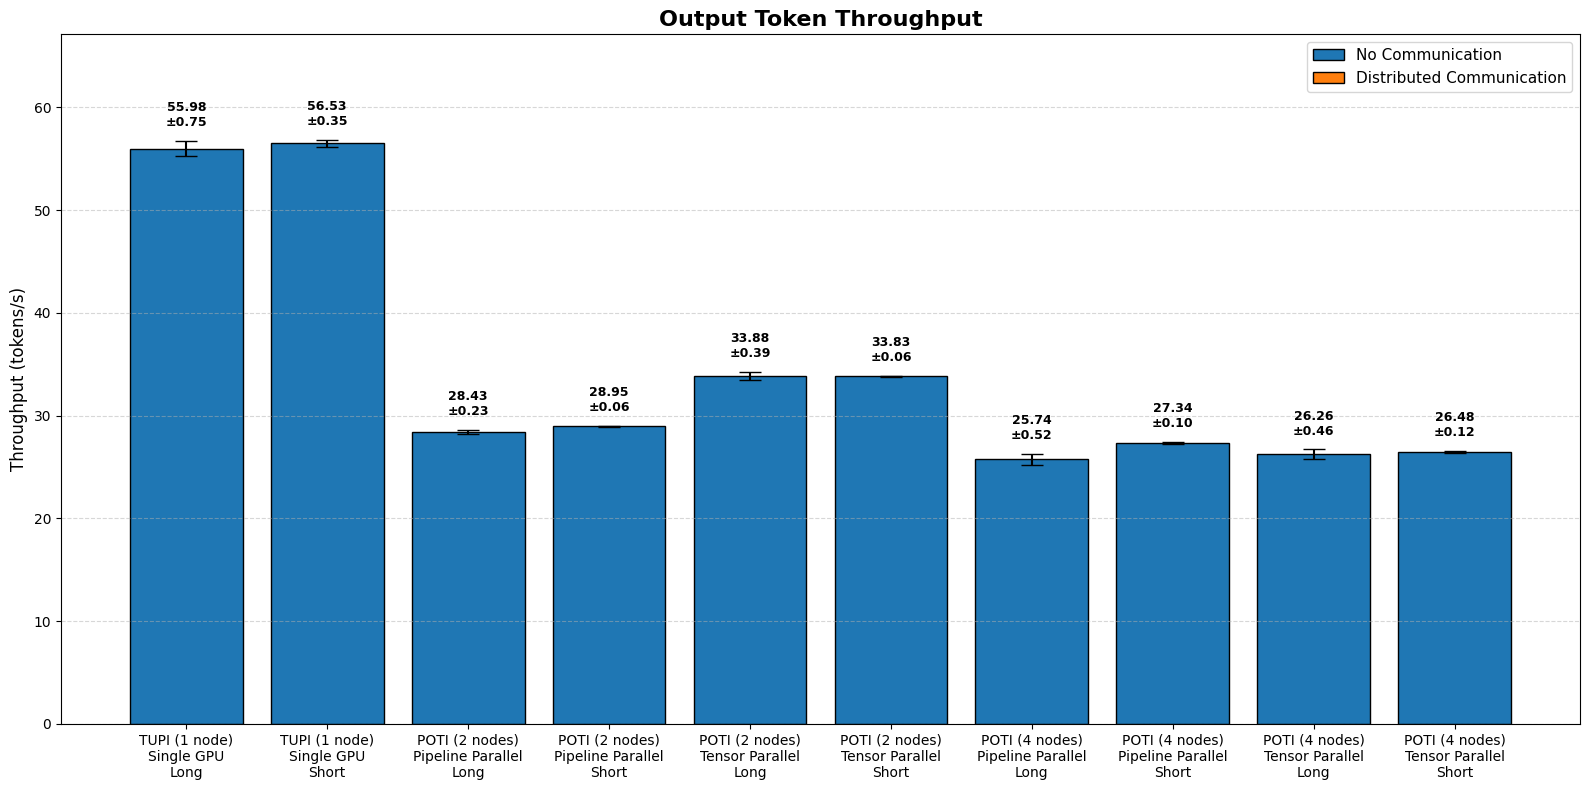

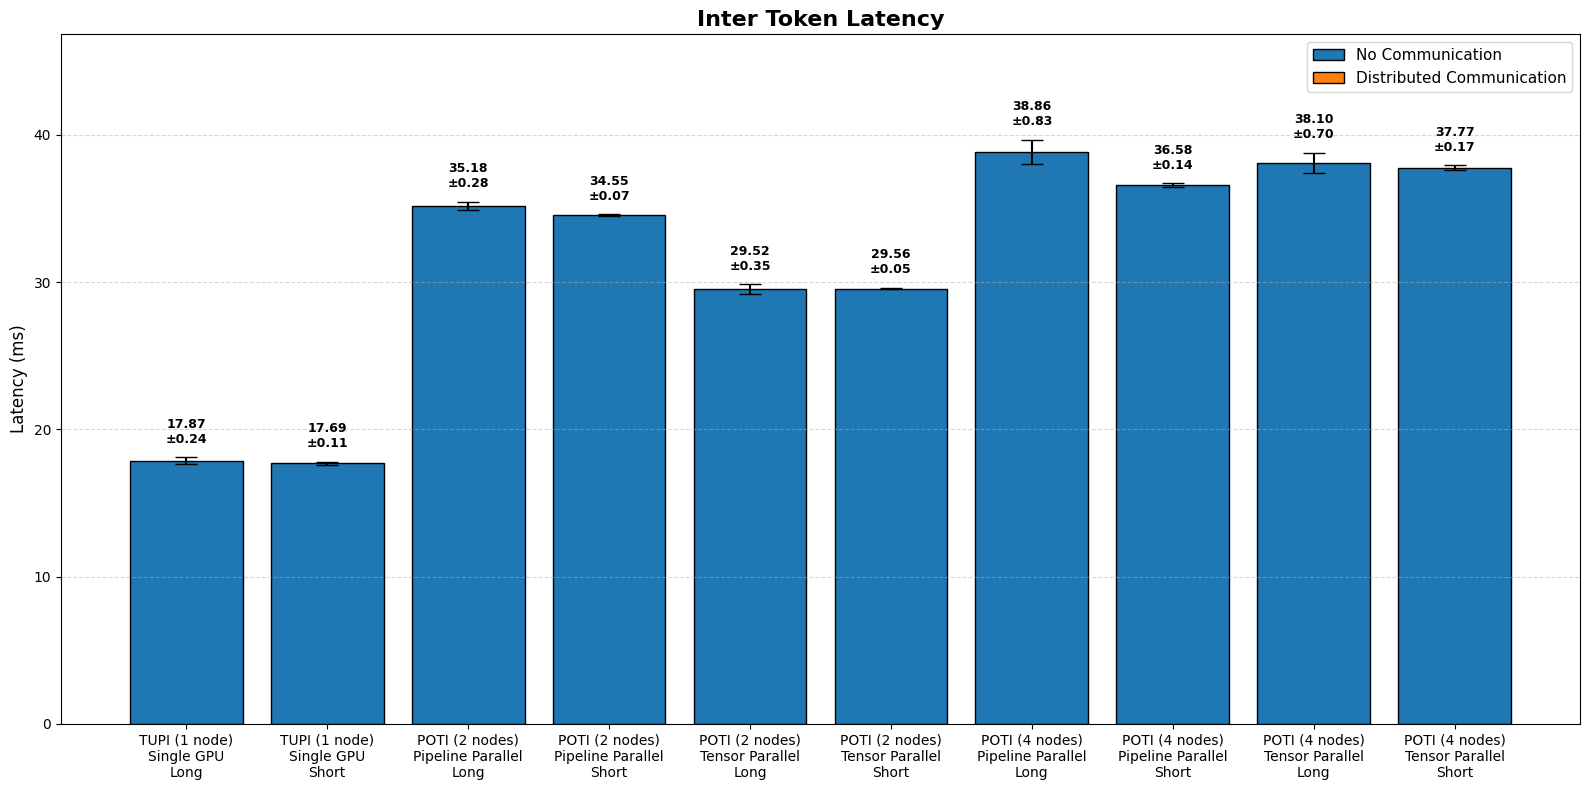

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# FIX BOOLEAN COLUMN
# =========================================================
df['is_communication'] = (
    df['is_communication']
    .replace({
        True: True,
        False: False,
        'True': True,
        'False': False,
        'true': True,
        'false': False
    })
    .astype(bool)
)

# =========================================================
# PRETTY LABELS
# =========================================================
def format_experiment_name(name):

    if not isinstance(name, str):
        return str(name)

    parts = name.split('_')

    try:
        # Example:
        # N2_poti_TP_long_r1_780629

        node_part = parts[0]
        machine = parts[1].upper()
        strategy = parts[2]
        workload = parts[3]

        n_nodes = int(node_part.replace('N', ''))

        # =================================================
        # STRATEGY NAMES
        # =================================================
        strategy_map = {
            'none': 'Single GPU',
            'TP': 'Tensor Parallel',
            'PP': 'Pipeline Parallel'
        }

        strategy_name = strategy_map.get(strategy, strategy)

        # =================================================
        # WORKLOAD
        # =================================================
        workload_name = workload.capitalize()

        # =================================================
        # FINAL LABEL
        # =================================================
        return (
            f"{machine} ({n_nodes} node{'s' if n_nodes > 1 else ''})\n"
            f"{strategy_name}\n"
            f"{workload_name}"
        )

    except Exception:
        return name


# =========================================================
# MAIN PLOTS
# =========================================================
for avg_col in metrics_to_plot:

    # =====================================================
    # FIND STD COLUMN
    # =====================================================
    if avg_col.endswith('_avg_ms'):
        std_col = avg_col.replace('_avg_ms', '_std_ms')

    else:
        std_col = avg_col.replace('_avg', '_std')

    # =====================================================
    # CHECK COLUMN EXISTS
    # =====================================================
    if avg_col not in df.columns:
        print(f"Skipping {avg_col}: column not found.")
        continue

    # =====================================================
    # BUILD PLOT DF
    # =====================================================
    columns = [
        'experiment_name',
        'machine_name',
        'is_communication',
        avg_col
    ]

    if std_col in df.columns:
        columns.append(std_col)

    plot_df = df[columns].copy()

    # =====================================================
    # DROP NAN
    # =====================================================
    plot_df = plot_df.dropna(subset=[avg_col])

    if plot_df.empty:
        continue

    # =====================================================
    # SORT
    # =====================================================
    plot_df = plot_df.sort_values(
        by='experiment_name'
    ).reset_index(drop=True)

    # =====================================================
    # PRETTY NAMES
    # =====================================================
    plot_df['pretty_name'] = (
        plot_df['experiment_name']
        .apply(format_experiment_name)
    )

    # =====================================================
    # X/Y VALUES
    # =====================================================
    x = np.arange(len(plot_df))
    y = plot_df[avg_col].values

    # =====================================================
    # STD
    # =====================================================
    has_std = (
        std_col in plot_df.columns
        and plot_df[std_col].notna().any()
    )

    yerr = (
        plot_df[std_col].values
        if has_std else None
    )

    # =====================================================
    # COLORS
    # =====================================================
    colors = np.where(
        plot_df['is_communication'],
        'tab:orange',   # communication
        'tab:blue'      # no communication
    )

    # =====================================================
    # FIGURE
    # =====================================================
    plt.figure(figsize=(16, 8))

    bars = plt.bar(
        x,
        y,
        yerr=yerr,
        capsize=8 if has_std else 0,
        color=colors,
        edgecolor='black',
        linewidth=1
    )

    # =====================================================
    # VALUE LABELS
    # =====================================================
    offset = 0.02 * np.nanmax(y)

    max_height = 0

    for i, (xi, yi) in enumerate(zip(x, y)):

        label = f"{yi:.2f}"

        if has_std:

            std_val = yerr[i]

            if (
                not np.isnan(std_val)
                and std_val > 0
            ):

                label += f"\n±{std_val:.2f}"

                y_pos = yi + std_val + offset

                max_height = max(
                    max_height,
                    yi + std_val
                )

            else:

                y_pos = yi + offset

                max_height = max(
                    max_height,
                    yi
                )

        else:

            y_pos = yi + offset

            max_height = max(
                max_height,
                yi
            )

        plt.text(
            xi,
            y_pos,
            label,
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # =====================================================
    # Y LIMITS
    # =====================================================
    plt.ylim(
        0,
        max_height * 1.18
    )

    # =====================================================
    # X LABELS
    # =====================================================
    plt.xticks(
        x,
        plot_df['pretty_name'],
        rotation=0,
        fontsize=10
    )

    # =====================================================
    # LEGEND
    # =====================================================
    legend_elements = [
        Patch(
            facecolor='tab:blue',
            edgecolor='black',
            label='No Communication'
        ),
        Patch(
            facecolor='tab:orange',
            edgecolor='black',
            label='Distributed Communication'
        )
    ]

    plt.legend(
        handles=legend_elements,
        fontsize=11
    )

    # =====================================================
    # TITLES
    # =====================================================
    plt.title(
        pretty_metric_name(avg_col),
        fontsize=16,
        fontweight='bold'
    )

    plt.ylabel(
        get_ylabel(avg_col),
        fontsize=12
    )

    # =====================================================
    # GRID
    # =====================================================
    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.5
    )

    # =====================================================
    # LAYOUT
    # =====================================================
    plt.tight_layout()

    # =====================================================
    # SHOW
    # =====================================================
    plt.show()

Focusing strictly on the time metrics, the results show a more nuanced trade-off between computation and communication that depends on the inference phase. The single-machine configuration achieves the lowest overall request latency and inter-token latency, as all computation is local and no synchronization or data transfer is required. When tensor parallelism is introduced, latency increases due to frequent inter-GPU communication at every layer, but this overhead remains relatively controlled because computation is still performed concurrently across devices, leading to good inter-token latency during the decode phase.

Pipeline parallelism, however, exhibits contrasting behavior between phases. During prefill, it can achieve significantly lower time to first token (TTFT), especially for long inputs, because different pipeline stages process multiple tokens concurrently once the pipeline is filled. This allows the workload to be effectively distributed across GPUs, reducing the initial response time. In contrast, during the decode phase, where tokens are generated sequentially, pipeline parallelism becomes less efficient. Each token must traverse all stages in order, introducing synchronization delays and idle periods (pipeline bubbles), which increases inter-token latency. As a result, while pipeline parallelism can outperform tensor parallelism in TTFT, it tends to have worse per-token latency and, in many cases, higher overall request latency due to these sequential dependencies.